# 데이터 수집하기
- Twitter Scraper 활용하여 twitter 데이터 수집

In [1]:
import re
import csv
from getpass import getpass
from time import sleep
from selenium.webdriver.common.keys import Keys
from selenium.common.exceptions import NoSuchElementException
from selenium.webdriver import Chrome

from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.by import By

def get_tweet_data(card):
    """Extract data from tweet card"""
    username = card.find_element_by_xpath('.//span').text
    try:
        handle = card.find_element_by_xpath('.//span[contains(text(), "@")]').text
    except NoSuchElementException:
        return
    
    try:
        postdate = card.find_element_by_xpath('.//time').get_attribute('datetime')
    except NoSuchElementException:
        return
    
    comment = card.find_element_by_xpath('.//div[2]/div[2]/div[1]').text
    responding = card.find_element_by_xpath('.//div[2]/div[2]/div[2]').text
    text = comment + responding
    reply_cnt = card.find_element_by_xpath('.//div[@data-testid="reply"]').text
    retweet_cnt = card.find_element_by_xpath('.//div[@data-testid="retweet"]').text
    like_cnt = card.find_element_by_xpath('.//div[@data-testid="like"]').text
    
    # get a string of all emojis contained in the tweet
    """Emojis are stored as images... so I convert the filename, which is stored as unicode, into 
    the emoji character."""
    emoji_tags = card.find_elements_by_xpath('.//img[contains(@src, "emoji")]')
    emoji_list = []
    for tag in emoji_tags:
        filename = tag.get_attribute('src')
        try:
            emoji = chr(int(re.search(r'svg\/([a-z0-9]+)\.svg', filename).group(1), base=16))
        except AttributeError:
            continue
        if emoji:
            emoji_list.append(emoji)
    emojis = ' '.join(emoji_list)
    
    tweet = (username, handle, postdate, text, emojis, reply_cnt, retweet_cnt, like_cnt)
    return tweet

In [2]:
# application variables
user = input('username: ')
my_password = getpass('Password: ')
search_term = input('search term: ')

# create instance of web driver
driver = Chrome()

# navigate to login screen
driver.get('https://www.twitter.com/login')
driver.maximize_window()
# sleep(10)

# username = driver.find_element_by_xpath('//input[@name="session[username_or_email]"]')
username = WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.XPATH, '//input[@name="session[username_or_email]"]')))
username.send_keys(user)
# sleep(10)

# password = driver.find_element_by_xpath('//input[@name="session[password]"]')
password = WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.XPATH, '//input[@name="session[password]"]')))
password.send_keys(my_password)
password.send_keys(Keys.RETURN)
# sleep(10)

# find search input and search for term
# search_input = driver.find_element_by_xpath('//input[@aria-label="Search query"]')
search_input = WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.XPATH, '//input[@aria-label="Search query"]')))
search_input.send_keys(search_term)
search_input.send_keys(Keys.RETURN)

# navigate to historical 'latest' tab
#driver.find_element_by_link_text('Latest').click()

WebDriverWait(driver, 10).until(EC.presence_of_element_located((By.LINK_TEXT, 'Latest'))).click()
sleep(10)

# search term =  #국내여행 since:2020-01-01 until:2020-12-31

username: fxo0029
Password: ········
search term: #국내여행 since:2020-01-01 until:2020-12-31


In [3]:
# get all tweets on the page
data = []
tweet_ids = set()
last_position = driver.execute_script('return window.pageYOffset;')
scrolling = True

while scrolling:
    
    page_cards = driver.find_elements_by_xpath('//div[@data-testid="tweet"]')
    
    for card in page_cards[-15:]:
        tweet = get_tweet_data(card)
        if tweet:
            tweet_id = ''.join(tweet)
            if tweet_id not in tweet_ids:
                tweet_ids.add(tweet_id)
                data.append(tweet)
            
    scroll_attempt = 0
    while True:
        # check scroll position
        driver.execute_script('window.scrollTo(0, document.body.scrollHeight);')
        sleep(2)
        curr_position = driver.execute_script("return window.pageYOffset;")
        
        if last_position == curr_position:
            scroll_attempt += 1
            
            # end of scroll region
            if scroll_attempt >= 3:
                scrolling = False
                break
            else:
                sleep(2) # attempt another scroll
        else:
            last_position = curr_position
            break

len(data)

706

#  tweet data 저장하기

In [4]:
with open('tweets.csv', 'w', newline='', encoding='utf-8') as f:
    header = ['UserName', 'Handle', 'Timestamp', 'Comments', 'Likes', 'Retweets', 'text']
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(data)

# 데이터 불러오기

In [5]:
import json
import os
import re
import pandas as pd

from pprint import pprint
from konlpy.tag import Okt
from eunjeon import Mecab

In [6]:
tweets_doc = pd.read_csv('tweets.csv')
tweets_doc

,UserName,Handle,Timestamp,Comments,Likes,Retweets,text
GvC,@HPpoijbb,2020-12-30T08:06:04.000Z,아무생각없이놀고싶다.\n#국내여행 #해외여행 #레저 #데이트 #여행 #드라이브,NaN,NaN,NaN,NaN
농촌여행모든것 웰촌,@welchontour,2020-12-30T08:05:23.000Z,"""몸도 마음도 건강해지는 웰빙 농촌여행! 연봉정마을이 있다. 마을 특산품인 케일을 ...",▶,NaN,NaN,1
강다방 게스트하우스,@kangdbang,2020-12-30T00:27:49.000Z,의도치 않은 강릉의 하천 시리즈\n#신리천 #백로 #강릉의하천들 #강릉풍경 #강릉살...,NaN,NaN,NaN,NaN
yarbongs,@yarbongs,2020-12-29T16:13:00.000Z,"https://enlte.tistory.com/121 - #광주 #자전거도로 코스,...",NaN,NaN,NaN,NaN
오션갤러리호텔앤리조트,@oceangallery__,2020-12-29T07:38:53.000Z,제주여행의 푸른 밤\n고품격 명품 리조트 오션갤러리\n\n당신이 꿈꾸는 여행이 한 ...,NaN,3.0,1.0,6
...,...,...,...,...,...,...,...
강다방 게스트하우스,@kangdbang,2020-07-16T08:45:02.000Z,[내일로 여행 3일차] 광주 \n 목포\n목포의 숙소\n#강다방아님주의 #수다방 #...,▶,NaN,NaN,NaN
트래비 매거진,@TravieMagazine,2020-07-16T00:47:11.000Z,"찍고, 먹고, 힐링까지~ 관광도시로 거듭나는 울산으로 떠나는 '인생샷 투어'\nht...",NaN,NaN,NaN,NaN
수니천사,@sundeok9745,2020-07-15T10:00:06.000Z,닭갈비와 막국수로 유명한 춘천에 가면 소양강 스카이워크를 걸어보자\nhttps://...,NaN,NaN,1.0,NaN
강다방 게스트하우스,@kangdbang,2020-07-15T08:53:05.000Z,[내일로 여행 3일차] 광주 \n 목포\n목포의 밤\n#유달산 #목포야경 #목포원도...,▶,NaN,NaN,NaN


In [7]:
# 
corpus = tweets_doc['Timestamp']
corpus

GvC                  아무생각없이놀고싶다.\n#국내여행 #해외여행 #레저 #데이트 #여행 #드라이브
농촌여행모든것 웰촌     "몸도 마음도 건강해지는 웰빙 농촌여행! 연봉정마을이 있다. 마을 특산품인 케일을 ...
강다방 게스트하우스     의도치 않은 강릉의 하천 시리즈\n#신리천 #백로 #강릉의하천들 #강릉풍경 #강릉살...
yarbongs       https://enlte.tistory.com/121 - #광주 #자전거도로 코스,...
오션갤러리호텔앤리조트    제주여행의 푸른 밤\n고품격 명품 리조트 오션갤러리\n\n당신이 꿈꾸는 여행이 한 ...
                                     ...                        
강다방 게스트하우스     [내일로 여행 3일차] 광주 \n 목포\n목포의 숙소\n#강다방아님주의 #수다방 #...
트래비 매거진        찍고, 먹고, 힐링까지~ 관광도시로 거듭나는 울산으로 떠나는 '인생샷 투어'\nht...
수니천사           닭갈비와 막국수로 유명한 춘천에 가면 소양강 스카이워크를 걸어보자\nhttps://...
강다방 게스트하우스     [내일로 여행 3일차] 광주 \n 목포\n목포의 밤\n#유달산 #목포야경 #목포원도...
강다방 게스트하우스     [내일로 여행 3일차] 광주 \n 목포\n목포의 밤\n#유달산 #목포야경 #목포원도...
Name: Timestamp, Length: 706, dtype: object

# 데이터 전처리

In [8]:
# 데이터 전처리를 위한 전체 데이터의 특징을 빈도분석으로 파악

import nltk

total_tokens = [token for msg in corpus for token in str(msg).split()]
print(len(total_tokens))

18705


In [9]:
text = nltk.Text(total_tokens, name='Tweet')
print(len(set(text.tokens)))
pprint(text.vocab().most_common(10))

5590
[('#국내여행', 696),
 ('#강원도', 274),
 ('#이번엔강원도', 259),
 ('#yesblog', 258),
 ('#이번엔경주', 257),
 ('#경주', 238),
 ('#베스트셀러', 207),
 ('#그시절서툰유럽여행기', 185),
 ('#제주도', 172),
 ('#그시절서툰삼국지기행', 164)]


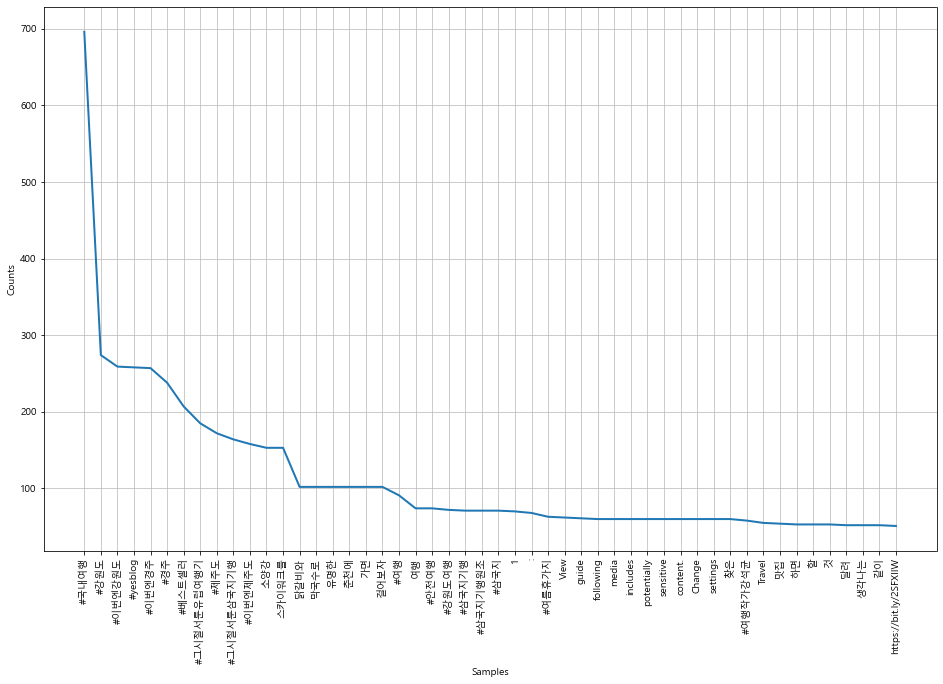

In [10]:
from matplotlib import font_manager, rc

import matplotlib as mpl
import matplotlib.pyplot as plt
import platform

%matplotlib inline


# 그래프에서 마이너스 폰트 깨지는 문제에 대한 대처
path = 'C:/Windows/Fonts/malgun.ttf'

if platform.system() == "Darwind":
    rc('font', family='AppleGothic')
    
elif platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
    
else:
    print('Unknown system ... ')

plt.figure(figsize=(16, 10))
text.plot(50)

# WordCloud 그리기

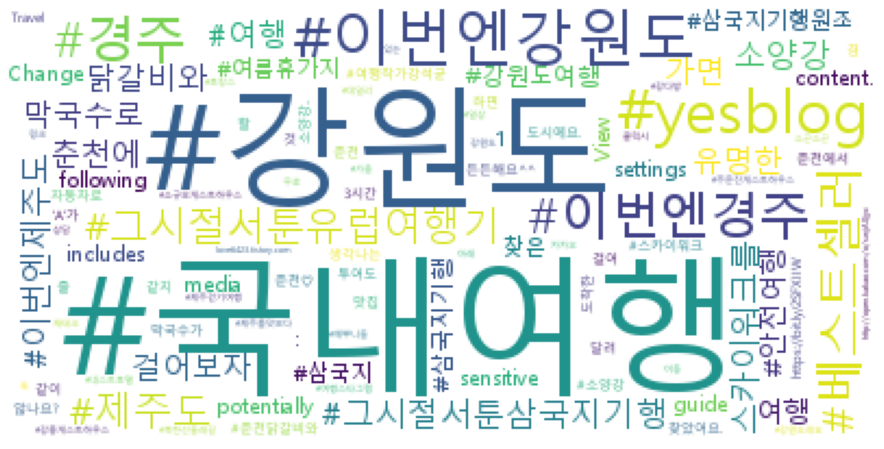

In [11]:
from wordcloud import WordCloud

data = text.vocab().most_common(100)

# for win : font_path='c:/Windows/Fonts/malgun.ttf'
wordcloud = WordCloud(font_path='C:/Windows/Fonts/malgun.ttf',
                      relative_scaling = 0.2,
                      #stopwords=STOPWORDS,
                      background_color='white',
                      ).generate_from_frequencies(dict(data))
plt.figure(figsize=(16,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()